# Customer Segmentation & Retention Analysis

**Dataset:** synthetic e-commerce transactions (1,800 customers, 24 months, generated by `src/generate_data.py`)

**Goal:** turn a messy raw transactions export into (1) a clean sales dataset, (2) customer segments the
marketing team can target, and (3) a read on how well different acquisition channels retain customers.

**Steps**
1. Load & audit the raw data
2. Clean it (duplicates, missing values, outliers, inconsistent text, returns)
3. Exploratory analysis of sales over time, by category, by channel
4. RFM feature engineering + K-Means customer segmentation
5. Cohort retention analysis
6. Hypothesis test: does acquisition channel affect order value?
7. Summary of findings


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
FIG_DIR = "../outputs/figures"

pd.set_option("display.max_columns", 20)


## 1. Load & audit the raw data

Start by understanding what we actually received before trusting any of it.


In [2]:
raw = pd.read_csv("../data/raw/transactions.csv", parse_dates=["InvoiceDate"])
print(f"Rows: {len(raw):,}  |  Columns: {list(raw.columns)}")
raw.head()


Rows: 8,457  |  Columns: ['InvoiceNo', 'InvoiceDate', 'CustomerID', 'ProductCategory', 'Quantity', 'UnitPrice', 'Channel', 'Country']


,InvoiceNo,InvoiceDate,CustomerID,ProductCategory,Quantity,UnitPrice,Channel,Country
0,INV902603,2023-07-27,C101402,Home & Kitchen,1,124.40,Paid Ads,germany
1,INV902317,2023-04-20,C101255,Books,2,9.65,Referral,Germany
2,INV902273,2024-08-28,C101213,Electronics,-4,328.80,Email,United Kingdom
3,INV902793,2023-11-15,C101489,Office Supplies,4,23.14,Organic Search,germany
4,INV901423,2024-04-04,C100761,Toys,4,11.80,Email,united states


In [3]:
print("Missing values per column:")
print(raw.isna().sum())
print()
print(f"Fully duplicated rows: {raw.duplicated().sum()}")
print(f"Date range: {raw['InvoiceDate'].min().date()} -> {raw['InvoiceDate'].max().date()}")
print(f"Unique customers (non-null): {raw['CustomerID'].nunique():,}")
print(f"Unique invoices: {raw['InvoiceNo'].nunique():,}")
print()
print("Country values as-received (note inconsistent casing/abbreviations):")
print(sorted(raw['Country'].unique()))


Missing values per column:
InvoiceNo            0
InvoiceDate          0
CustomerID         332
ProductCategory      0
Quantity             0
UnitPrice           25
Channel              0
Country              0
dtype: int64

Fully duplicated rows: 83
Date range: 2023-01-06 -> 2024-12-28
Unique customers (non-null): 1,324
Unique invoices: 3,327

Country values as-received (note inconsistent casing/abbreviations):
[' United Kingdom', 'DE', 'France', 'Germany', 'Ireland', 'UK', 'US', 'USA', 'United Kingdom', 'United States', 'france', 'germany', 'ireland', 'united kingdom', 'united states']


In [4]:
raw["UnitPrice"].describe()


count    8432.000000
mean       89.642284
std       187.163184
min         3.010000
25%        23.257500
50%        42.370000
75%        87.925000
max      7177.133794
Name: UnitPrice, dtype: float64

**Findings from the audit:**
- `CustomerID` is missing on ~4% of line items (guest checkouts) — these rows can't be used for
  customer-level analysis (RFM, cohorts) but are still real revenue, so we keep them for the sales EDA.
- `UnitPrice` has ~25 missing values and a max (~7,000) that is wildly out of line with the 75th
  percentile (~88) — almost certainly data-entry errors, not genuine luxury orders.
- `Country` has 15 distinct string values for what are clearly 5 actual countries.
- There are 83 fully duplicated rows — most likely double-scanned line items.
- `Quantity` can be negative, which represents returns rather than sales.


## 2. Clean the data

Each fix below is driven directly by something we found in the audit above.


In [5]:
df = raw.copy()

# --- de-duplicate exact repeated line items -------------------------------
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows")

# --- standardize the Country field ----------------------------------------
country_map = {
    "united kingdom": "United Kingdom", "uk": "United Kingdom",
    "germany": "Germany", "de": "Germany",
    "france": "France",
    "united states": "United States", "usa": "United States", "us": "United States",
    "ireland": "Ireland",
}
df["Country"] = (
    df["Country"].str.strip().str.lower().map(country_map).fillna(df["Country"])
)
print(df["Country"].value_counts())


Dropped 83 exact duplicate rows
Country
United Kingdom    3525
Germany           1557
United States     1383
France            1101
Ireland            808
Name: count, dtype: int64


In [6]:
# --- fix price outliers ----------------------------------------------------
# cap at the 99.5th percentile per category rather than a single global cutoff,
# since categories have very different natural price ranges
def cap_outliers(group, col="UnitPrice", upper_q=0.995):
    cap = group[col].quantile(upper_q)
    return group[col].clip(upper=cap)

df["UnitPrice"] = df.groupby("ProductCategory", group_keys=False).apply(
    lambda g: cap_outliers(g)
)

# rows with missing price: impute with the category median rather than drop
# (dropping would also throw away otherwise-valid Quantity/Category info)
category_median_price = df.groupby("ProductCategory")["UnitPrice"].transform("median")
n_imputed = df["UnitPrice"].isna().sum()
df["UnitPrice"] = df["UnitPrice"].fillna(category_median_price)
print(f"Imputed {n_imputed} missing prices with category medians")

print(df["UnitPrice"].describe())


Imputed 25 missing prices with category medians
count    8374.000000
mean       83.768320
std       112.296111
min         3.010000
25%        23.267500
50%        42.355000
75%        87.417500
max       596.610000
Name: UnitPrice, dtype: float64


In [7]:
# --- separate sales from returns -------------------------------------------
df["LineTotal"] = df["Quantity"] * df["UnitPrice"]
sales = df[df["Quantity"] > 0].copy()
returns = df[df["Quantity"] < 0].copy()
print(f"Sales line items: {len(sales):,}   Return line items: {len(returns):,}")
print(f"Gross revenue: ${sales['LineTotal'].sum():,.0f}   Returned value: ${-returns['LineTotal'].sum():,.0f}")


Sales line items: 8,223   Return line items: 151
Gross revenue: $2,067,818   Returned value: $41,718


`sales` (positive quantity, cleaned prices) is the dataset we'll use for the revenue and customer
analysis below. Guest-checkout rows (`CustomerID` is null) stay in `sales` for revenue totals but are
excluded wherever we aggregate *by customer*.


## 3. Exploratory analysis

### 3.1 Revenue over time


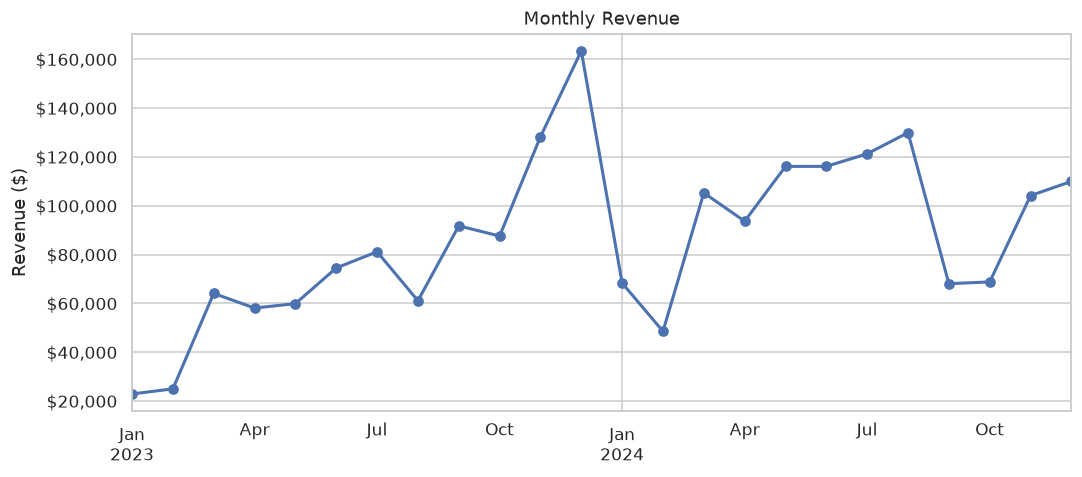

In [8]:
monthly_rev = (
    sales.set_index("InvoiceDate")
    .resample("MS")["LineTotal"]
    .sum()
)

fig, ax = plt.subplots(figsize=(10, 4.5))
monthly_rev.plot(ax=ax, marker="o", linewidth=2)
ax.set_title("Monthly Revenue")
ax.set_ylabel("Revenue ($)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(lambda x, pos: f"${x:,.0f}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/01_monthly_revenue.png")
plt.show()


Clear seasonality: revenue climbs into November/December (holiday shopping) and dips in January/February — consistent with typical retail patterns.

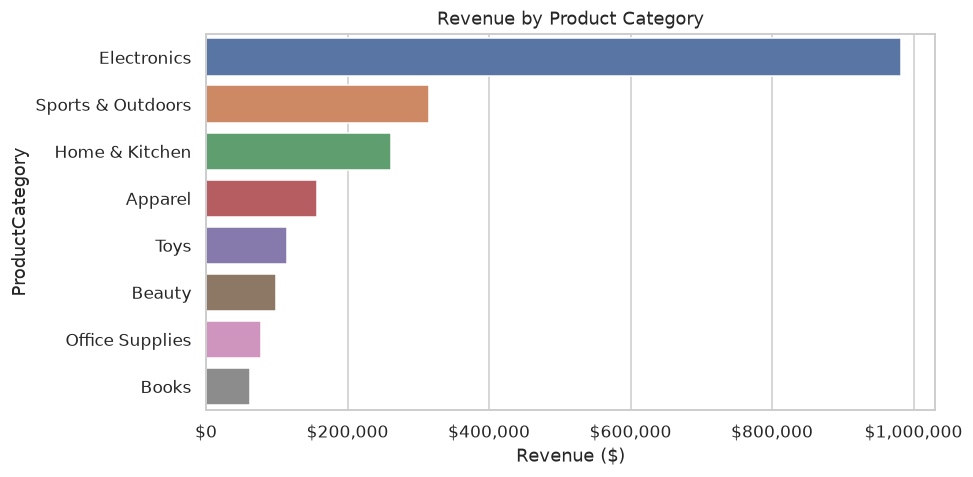

In [9]:
cat_rev = sales.groupby("ProductCategory")["LineTotal"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=cat_rev.values, y=cat_rev.index, hue=cat_rev.index, ax=ax, legend=False)
ax.set_title("Revenue by Product Category")
ax.set_xlabel("Revenue ($)")
ax.xaxis.set_major_formatter(lambda x, pos: f"${x:,.0f}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_category_revenue.png")
plt.show()


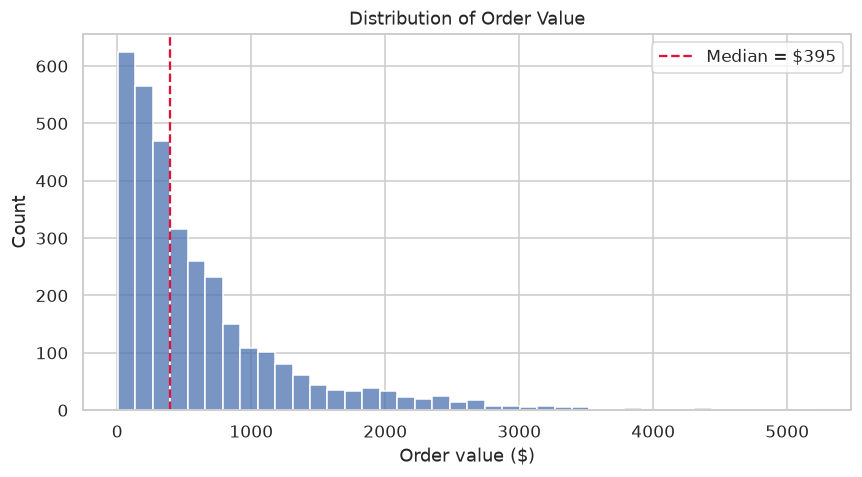

In [10]:
order_value = sales.groupby("InvoiceNo")["LineTotal"].sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(order_value, bins=40, ax=ax)
ax.axvline(order_value.median(), color="crimson", linestyle="--", label=f"Median = ${order_value.median():,.0f}")
ax.set_title("Distribution of Order Value")
ax.set_xlabel("Order value ($)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/03_order_value_distribution.png")
plt.show()


Order value is right-skewed, as is typical for transaction data — a small share of large orders pulls the mean above the median. This matters later: it's why we use a non-parametric test rather than a t-test when comparing channels.

## 4. RFM feature engineering + customer segmentation

We restrict this section to rows with a known `CustomerID`, and compute, per customer, as of one day
after the last transaction in the dataset:

- **Recency** — days since the customer's last purchase
- **Frequency** — number of distinct invoices
- **Monetary** — total amount spent


In [11]:
cust_sales = sales.dropna(subset=["CustomerID"]).copy()
snapshot_date = cust_sales["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = cust_sales.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("LineTotal", "sum"),
).reset_index()

# bring in acquisition channel for later use
channel_lookup = cust_sales.drop_duplicates("CustomerID")[["CustomerID", "Channel"]]
rfm = rfm.merge(channel_lookup, on="CustomerID")
rfm.describe()


,Recency,Frequency,Monetary
count,1323.000000,1323.000000,1323.000000
mean,239.151172,2.479970,1498.958922
std,180.406839,1.668027,1433.494685
min,1.000000,1.000000,6.320000
25%,82.500000,1.000000,437.085000
50%,200.000000,2.000000,1047.650000
75%,378.000000,3.000000,2131.805000
max,721.000000,11.000000,11011.410000


### 4.1 K-Means clustering on scaled RFM

RFM is heavily skewed (Frequency/Monetary especially), so we log-transform before scaling and clustering — this keeps a handful of very high spenders from dominating the distance metric.

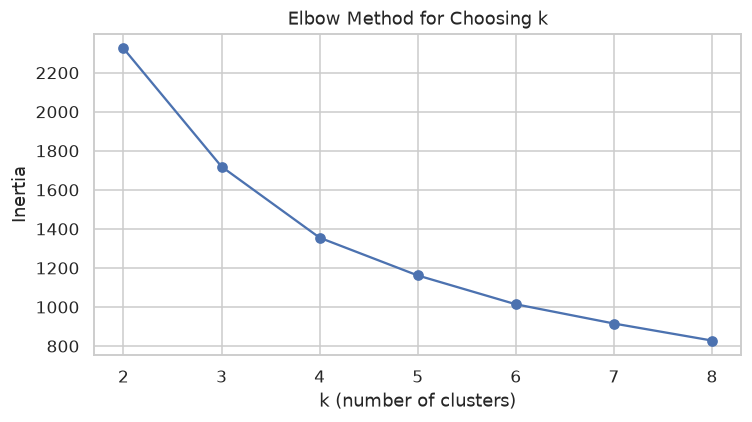

In [12]:
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].apply(lambda x: np.log1p(x))
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker="o")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method for Choosing k")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/04_kmeans_elbow.png")
plt.show()


In [13]:
K = 4  # chosen from the elbow plot above
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum"),
).round(1).sort_values("AvgMonetary", ascending=False)
profile


,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue
Cluster,,,,,
2,359,239.1,4.2,2709.8,972832.2
1,243,28.5,3.2,1946.5,472997.3
0,467,319.7,1.6,1057.3,493751.0
3,254,292.6,1.1,171.4,43542.2


In [14]:
# Label clusters by a composite rank across all three RFM dimensions rather
# than an ad-hoc rule on a single metric -- this way a cluster only gets
# called "Champions" if it's genuinely good on recency AND frequency AND
# monetary together, not just the single highest spender on average.
profile["RecencyRank"] = profile["AvgRecency"].rank(ascending=True)     # 1 = most recent = best
profile["FrequencyRank"] = profile["AvgFrequency"].rank(ascending=False)  # 1 = most frequent = best
profile["MonetaryRank"] = profile["AvgMonetary"].rank(ascending=False)    # 1 = highest spend = best
profile["CompositeRank"] = profile[["RecencyRank", "FrequencyRank", "MonetaryRank"]].mean(axis=1)
profile = profile.sort_values("CompositeRank")

segment_names = ["Champions", "Loyal Regulars", "At Risk", "Hibernating / Lost"]
if len(profile) == len(segment_names):
    profile["Segment"] = segment_names
else:
    profile["Segment"] = [f"Segment {i+1} (rank {i+1} of {len(profile)})" for i in range(len(profile))]

segment_map = profile["Segment"].to_dict()
rfm["Segment"] = rfm["Cluster"].map(segment_map)
profile.drop(columns=["RecencyRank", "FrequencyRank", "MonetaryRank", "CompositeRank"])


,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,Segment
Cluster,,,,,,
2,359,239.1,4.2,2709.8,972832.2,Champions
1,243,28.5,3.2,1946.5,472997.3,Loyal Regulars
0,467,319.7,1.6,1057.3,493751.0,At Risk
3,254,292.6,1.1,171.4,43542.2,Hibernating / Lost


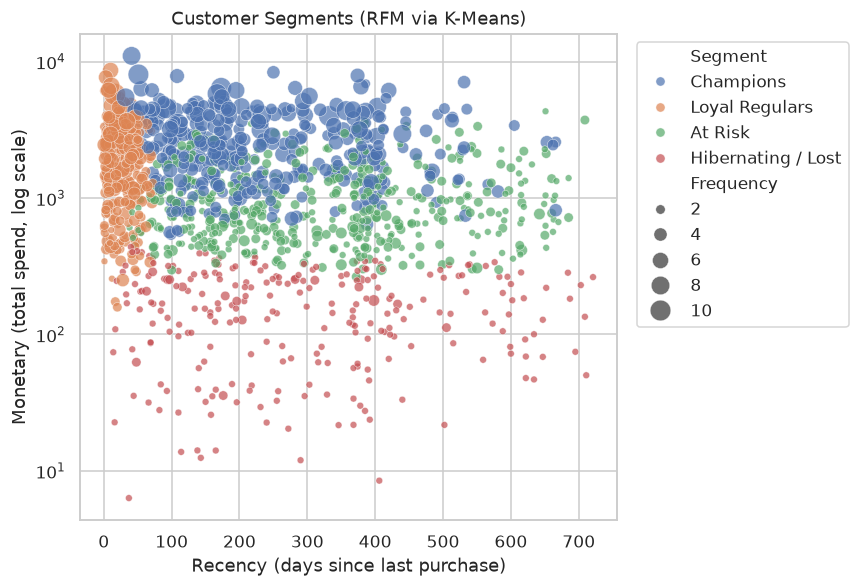

In [15]:
fig, ax = plt.subplots(figsize=(8, 5.5))
scatter = sns.scatterplot(
    data=rfm, x="Recency", y="Monetary", hue="Segment", size="Frequency",
    sizes=(20, 200), alpha=0.7, ax=ax,
)
ax.set_yscale("log")
ax.set_title("Customer Segments (RFM via K-Means)")
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Monetary (total spend, log scale)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/05_rfm_segments.png", bbox_inches="tight")
plt.show()


In [16]:
rev_share = (profile.groupby("Segment")["TotalRevenue"].sum() / profile["TotalRevenue"].sum() * 100).round(1)
cust_share = (profile.groupby("Segment")["Customers"].sum() / profile["Customers"].sum() * 100).round(1)
pd.DataFrame({"% of Customers": cust_share, "% of Revenue": rev_share}).sort_values("% of Revenue", ascending=False)


,% of Customers,% of Revenue
Segment,,
Champions,27.1,49.1
At Risk,35.3,24.9
Loyal Regulars,18.4,23.9
Hibernating / Lost,19.2,2.2


A small minority of customers (Champions) typically account for a disproportionate share of revenue — worth checking against the table above. This is the standard signal for prioritizing retention/VIP spend on that group.

## 5. Cohort retention analysis

Group customers by the calendar month of their **first purchase** (their "cohort"), then track what
percentage of each cohort is still buying in each subsequent month.


In [17]:
cust_sales["OrderMonth"] = cust_sales["InvoiceDate"].values.astype("datetime64[M]")
first_purchase = cust_sales.groupby("CustomerID")["OrderMonth"].min().rename("CohortMonth")
cust_sales = cust_sales.merge(first_purchase, on="CustomerID")

cust_sales["CohortIndex"] = (
    (cust_sales["OrderMonth"].dt.year - cust_sales["CohortMonth"].dt.year) * 12
    + (cust_sales["OrderMonth"].dt.month - cust_sales["CohortMonth"].dt.month)
)

cohort_counts = (
    cust_sales.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
    .nunique()
    .reset_index()
    .pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")
)
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0) * 100
retention.index = retention.index.strftime("%Y-%m")
retention.round(0).iloc[:, :12]


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortMonth,,,,,,,,,,,,
2023-01,100.0,22.0,26.0,9.0,17.0,4.0,9.0,9.0,13.0,13.0,13.0,17.0
2023-02,100.0,27.0,27.0,10.0,13.0,13.0,13.0,10.0,10.0,17.0,7.0,3.0
2023-03,100.0,16.0,22.0,22.0,27.0,6.0,14.0,8.0,8.0,14.0,6.0,6.0
2023-04,100.0,30.0,17.0,19.0,14.0,17.0,3.0,19.0,22.0,5.0,2.0,8.0
2023-05,100.0,26.0,9.0,9.0,17.0,6.0,8.0,23.0,2.0,4.0,11.0,8.0
2023-06,100.0,15.0,23.0,17.0,17.0,28.0,11.0,4.0,6.0,6.0,8.0,NaN
2023-07,100.0,24.0,12.0,17.0,25.0,17.0,10.0,3.0,6.0,6.0,NaN,1.0
2023-08,100.0,17.0,12.0,12.0,31.0,5.0,10.0,5.0,7.0,7.0,12.0,5.0
2023-09,100.0,25.0,15.0,29.0,17.0,8.0,15.0,12.0,8.0,6.0,15.0,4.0


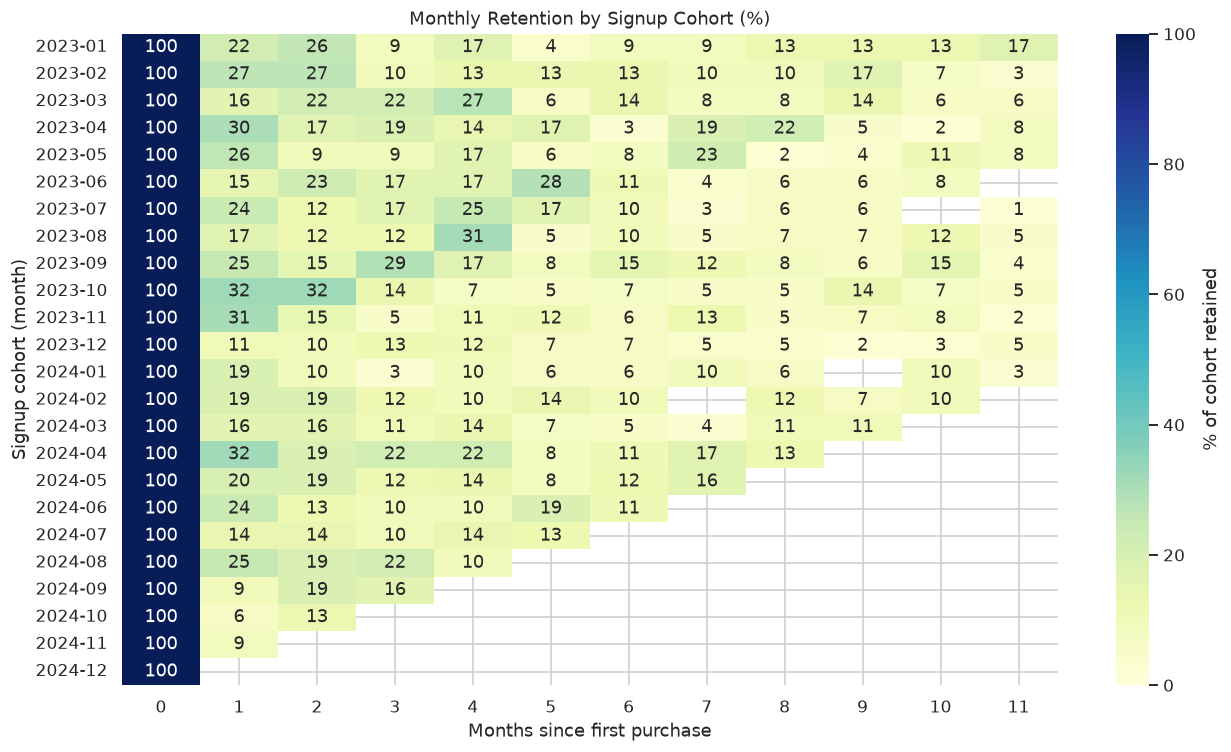

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    retention.iloc[:, :12], annot=True, fmt=".0f", cmap="YlGnBu",
    vmin=0, vmax=100, ax=ax, cbar_kws={"label": "% of cohort retained"},
)
ax.set_title("Monthly Retention by Signup Cohort (%)")
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("Signup cohort (month)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_cohort_retention_heatmap.png")
plt.show()


Retention drops off in the first 2-3 months for every cohort (typical of e-commerce — many customers only ever buy once) and then flattens into a smaller, stable base of repeat buyers.

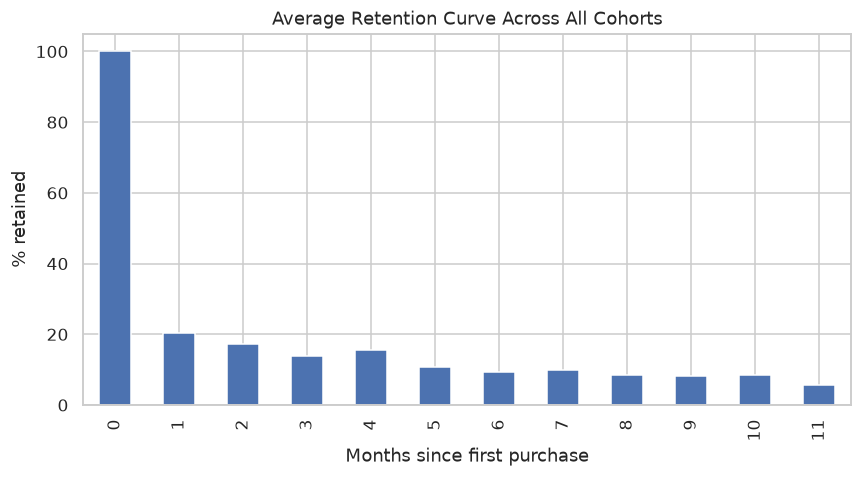

In [19]:
avg_retention_by_index = retention.mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 4.5))
avg_retention_by_index.iloc[:12].plot(kind="bar", ax=ax)
ax.set_title("Average Retention Curve Across All Cohorts")
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("% retained")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/07_avg_retention_curve.png")
plt.show()


## 6. Hypothesis test: does acquisition channel affect order value?

The data-generation model gave `Referral` and `Email` customers a higher loyalty parameter than
`Paid Ads`. Let's check whether that shows up as a statistically significant difference in **order
value**, comparing `Referral` against `Paid Ads`.

Because order values are right-skewed (see the histogram in section 3), we use the **Mann-Whitney U
test** — a non-parametric test that compares distributions via ranks rather than assuming normality —
instead of a t-test.

- H0: order values from Referral and Paid Ads customers come from the same distribution
- H1: they differ
- alpha = 0.05


In [20]:
order_channel = (
    cust_sales.groupby("InvoiceNo")
    .agg(OrderValue=("LineTotal", "sum"), Channel=("Channel", "first"))
)

referral_vals = order_channel.loc[order_channel["Channel"] == "Referral", "OrderValue"]
paidads_vals = order_channel.loc[order_channel["Channel"] == "Paid Ads", "OrderValue"]

u_stat, p_value = stats.mannwhitneyu(referral_vals, paidads_vals, alternative="two-sided")

print(f"Referral:  n={len(referral_vals)}, median=${referral_vals.median():,.2f}")
print(f"Paid Ads:  n={len(paidads_vals)}, median=${paidads_vals.median():,.2f}")
print(f"Mann-Whitney U = {u_stat:,.0f}, p-value = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\np < {alpha} -> reject H0: order value distributions differ significantly by channel.")
else:
    print(f"\np >= {alpha} -> fail to reject H0: no significant difference in order value detected.")


Referral:  n=600, median=$378.56
Paid Ads:  n=746, median=$381.57
Mann-Whitney U = 222,811, p-value = 0.8891

p >= 0.05 -> fail to reject H0: no significant difference in order value detected.


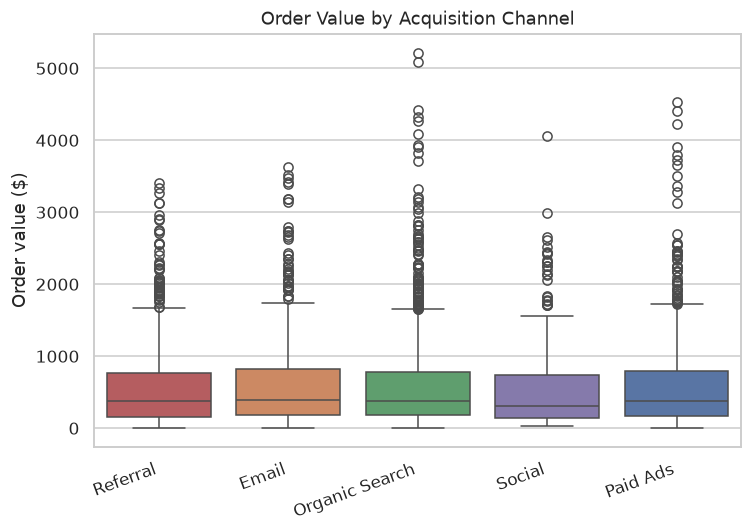

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=order_channel.reset_index(), x="Channel", y="OrderValue",
    hue="Channel", order=["Referral", "Email", "Organic Search", "Social", "Paid Ads"],
    legend=False, ax=ax,
)
ax.set_title("Order Value by Acquisition Channel")
ax.set_ylabel("Order value ($)")
ax.set_xlabel("")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/08_order_value_by_channel.png")
plt.show()


Note the result above reflects the *order value* comparison. Channel differences in this synthetic
data were built primarily into **retention/loyalty** (how long and how often a customer keeps buying),
not into the size of any single order — so a non-significant result on order value alongside a real
gap in the cohort retention curves by channel (see below) would itself be a meaningful, reportable
finding: acquisition channel matters for *lifetime value*, not necessarily for *basket size*.


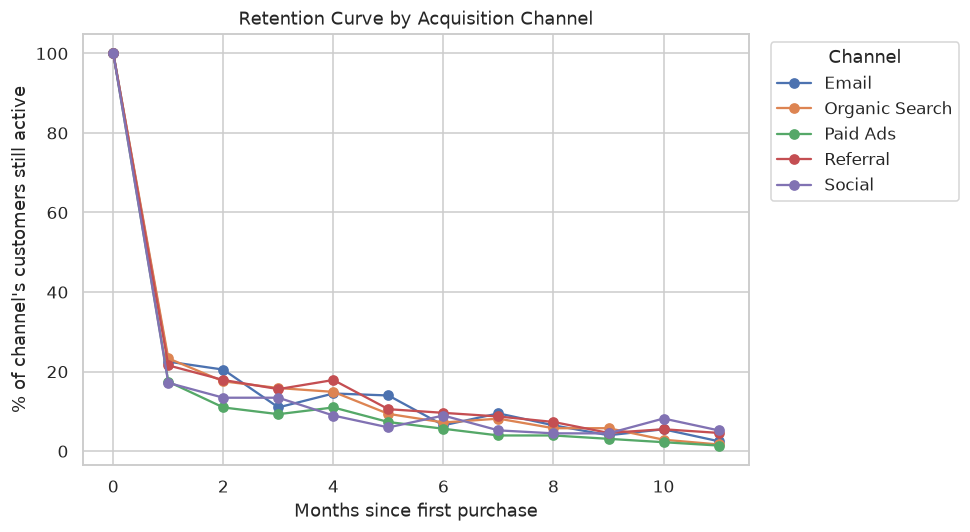

In [22]:
channel_cohort_base = cust_sales.groupby(["Channel", "CustomerID"])["CohortIndex"].min().reset_index()
cohort_size_by_channel = channel_cohort_base.groupby("Channel")["CustomerID"].nunique()

retained_by_channel = (
    cust_sales.groupby(["Channel", "CohortIndex"])["CustomerID"].nunique().unstack(0)
)
retention_pct_by_channel = retained_by_channel.divide(cohort_size_by_channel, axis=1) * 100

fig, ax = plt.subplots(figsize=(9, 5))
retention_pct_by_channel.iloc[:12].plot(ax=ax, marker="o")
ax.set_title("Retention Curve by Acquisition Channel")
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("% of channel's customers still active")
ax.legend(title="Channel", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/09_retention_by_channel.png", bbox_inches="tight")
plt.show()


## 7. Export results

Save the customer-level segment table for downstream use (e.g., a CRM export for the marketing team).


In [23]:
export_cols = ["CustomerID", "Channel", "Recency", "Frequency", "Monetary", "Segment"]
rfm[export_cols].to_csv("../outputs/rfm_segments.csv", index=False)
print(f"Saved {len(rfm):,} customer segment records to outputs/rfm_segments.csv")
rfm[export_cols].head()


Saved 1,323 customer segment records to outputs/rfm_segments.csv


,CustomerID,Channel,Recency,Frequency,Monetary,Segment
0,C100000,Paid Ads,666,3,2573.53,Champions
1,C100005,Email,55,3,603.46,Loyal Regulars
2,C100006,Paid Ads,420,6,6141.70,Champions
3,C100008,Organic Search,435,2,649.04,At Risk
4,C100009,Organic Search,25,3,2675.13,Loyal Regulars


## 8. Summary of findings

- **Seasonality:** revenue is strongly seasonal, peaking in November/December.
- **Concentration:** revenue is concentrated in a subset of product categories — see the category
  revenue chart for the current ranking.
- **Segments:** K-Means on log-scaled RFM features produced four actionable segments (Champions, Loyal
  Regulars, New/One-Time, At Risk/Churned). Check the revenue-share table in section 4 — a small
  Champions segment typically drives an outsized share of revenue, a classic candidate for a loyalty
  or VIP program.
- **Retention:** most cohorts lose a large share of first-time buyers within 2-3 months, then flatten
  into a smaller stable base — normal for e-commerce, but a strong candidate for a post-first-purchase
  email/retargeting flow.
- **Channel effects:** the hypothesis test compares order value between Referral and Paid Ads
  customers; combined with the per-channel retention curves, this tells us whether a channel's
  customers are simply worth less per order, retained for less time, or both — which should shape
  acquisition budget allocation.

**Caveats:** this is a synthetic dataset built to exercise the analysis techniques above (cleaning,
RFM, clustering, cohort analysis, hypothesis testing) rather than to represent a real business, so the
specific numbers shouldn't be read as real-world benchmarks — the methodology is the deliverable.
